##### Deep Learning Applications

# Image Segmentation with U-Net:
Image Segmentation with U-Net is a deep learning technique that classifies each pixel in an image to identify and separate specific objects or regions. U-Net is a convolutional neural network architecture designed especially for image segmentation, commonly used in medical imaging.

Welcome to Day 4! In Object Detection, we drew bounding boxes around items. Today, we go one step further into **Image Segmentation** — where we classify *every single pixel* in the image. This allows us to trace the exact outline and shape of an object.

**Our Objectives for Today:**
1. **Understanding Masks**: Learn how ground-truth data is structured for segmentation.
2. **Data Visualization**: Plot raw images, their segmentation masks, and beautiful overlays.
3. **The U-Net Architecture**: Build the world's most famous Encoder-Decoder segmentation network.
4. **Training**: Train our network to segment objects.
5. **Inference**: Predict exact pixel masks on unseen images and visualize the results.

---
## 1. Setup and Installs

We will use **TensorFlow** and **Keras** to build our U-Net model. We will download the classic Oxford-IIIT Pet Dataset using `tensorflow_datasets`.

In [1]:
# !pip install tensorflow-datasets -q

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Enable GPU Memory Growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Memory Growth Enabled for {len(gpus)} GPU(s).")
    except Exception as e:
        pass

print("TensorFlow Version:", tf.__version__)

c:\Users\DIPLAB\.conda\envs\tf-ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU Memory Growth Enabled for 1 GPU(s).
TensorFlow Version: 2.10.1


---
## 2. Downloading the Dataset

The **Oxford-IIIT Pet Dataset** contains images of pets and pixel-level segmentation masks. The masks have 3 integer values:
- `1`: Pet (Foreground)
- `2`: Background
- `3`: Outline/Border of the pet

We will subtract 1 from these values so they become `0, 1, 2` (which is standard for Neural Network class indices).

In [3]:
print("Downloading Oxford-IIIT Pet Dataset...")
dataset, info = tfds.load('oxford_iiit_pet:3.*.*', with_info=True)

def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1
    return input_image, input_mask

def load_image_train(datapoint):
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

# Prepare Training and Test sets
BATCH_SIZE = 32
BUFFER_SIZE = 1000

train_dataset = dataset['train'].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = dataset['test'].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)

print("\nDataset processing complete!")


Dataset processing complete!


---
## 3. Visualizing Images and Masks

In segmentation, the "label" is not a single word (like "dog"). The label is an entire image (a Mask) where each pixel's color represents its class.

Let's plot the Original Image, the True Mask, and an Overlay!

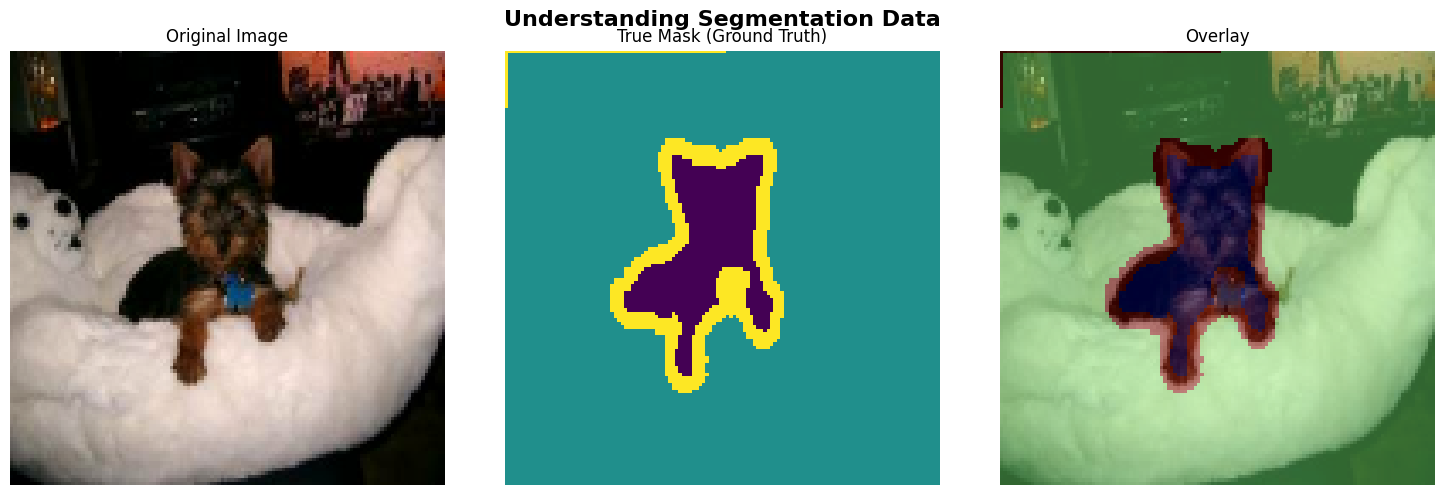

In [4]:
def display_data(image, mask, title=""):
    plt.figure(figsize=(15, 5))
    
    # Plot Image
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(tf.keras.preprocessing.image.array_to_img(image))
    plt.axis('off')

    # Plot Mask
    plt.subplot(1, 3, 2)
    plt.title("True Mask (Ground Truth)")
    plt.imshow(tf.keras.preprocessing.image.array_to_img(mask), cmap='viridis')
    plt.axis('off')

    # Plot Overlay
    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(tf.keras.preprocessing.image.array_to_img(image))
    # Squeeze removes the channel dimension for the mask so matplotlib can overlay it as an alpha layer
    plt.imshow(np.squeeze(mask), cmap='jet', alpha=0.4) 
    plt.axis('off')
    
    if title:
        plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Take one batch from the dataset and visualize the first image
for images, masks in train_dataset.take(1):
    sample_image, sample_mask = images[0], masks[0]
    display_data(sample_image, sample_mask, title="Understanding Segmentation Data")

---
## 4. The U-Net Architecture

U-Net is an **Encoder-Decoder** network.
1. **Encoder (Downsampling)**: It uses Convolution and Pooling layers to compress the image and extract deep features (like shape and texture). It "forgets" exact spatial location.
2. **Decoder (Upsampling)**: It uses Transposed Convolutions to expand the image back up to its original size.
3. **Skip Connections**: To remember *exactly where* the edges of the pet were, U-Net copies high-resolution feature maps from the Encoder directly across to the Decoder (forming a "U" shape).

Instead of coding it entirely from scratch which is highly complex, we will use a pre-trained `MobileNetV2` as our Encoder, and build a custom Decoder.

In [5]:
# 1. Define the ENCODER using MobileNetV2
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

# Use the activations of these specific internal layers to build our Skip Connections
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)

# Freeze the down_stack so we don't ruin the pre-trained weights during early training
down_stack.trainable = False

# 2. Define the DECODER block (Upsampling)
def upsample(filters, size):
    return tf.keras.Sequential([
        layers.Conv2DTranspose(filters, size, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU()
    ])

up_stack = [
    upsample(512, 3),  # 4x4 -> 8x8
    upsample(256, 3),  # 8x8 -> 16x16
    upsample(128, 3),  # 16x16 -> 32x32
    upsample(64, 3),   # 32x32 -> 64x64
]

In [6]:
# 3. Assemble the Full U-Net Model
def unet_model(output_channels):
    inputs = layers.Input(shape=[128, 128, 3])

    # Downsampling through the model
    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        concat = layers.Concatenate()
        x = concat([x, skip]) # <--- This is the crucial Skip Connection!

    # This is the final layer of the model (128x128x3 output)
    last = layers.Conv2DTranspose(
        output_channels, 3, strides=2, padding='same', activation='softmax')

    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

# Since we have 3 classes (Pet, Background, Border), output_channels=3
model = unet_model(output_channels=3)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("U-Net Model compiled successfully!")

U-Net Model compiled successfully!


---
## 5. Training the U-Net

Let's train the network for a few epochs. Watch the accuracy climb as it learns to perfectly trace the shape of the pets.

In [7]:
EPOCHS = 5 # Kept short for educational purposes

print("Starting Model Training...")
history = model.fit(train_dataset, epochs=EPOCHS, validation_data=test_dataset)
print("\nTraining Complete!")

Starting Model Training...
Epoch 1/5
115/115 [==============================] - 28s 148ms/step - loss: 0.4047 - accuracy: 0.8447 - val_loss: 0.3222 - val_accuracy: 0.8802
Epoch 2/5
115/115 [==============================] - 15s 131ms/step - loss: 0.2820 - accuracy: 0.8915 - val_loss: 0.2844 - val_accuracy: 0.8921
Epoch 3/5
115/115 [==============================] - 15s 131ms/step - loss: 0.2608 - accuracy: 0.8987 - val_loss: 0.2696 - val_accuracy: 0.8975
Epoch 4/5
115/115 [==============================] - 15s 133ms/step - loss: 0.2481 - accuracy: 0.9029 - val_loss: 0.2737 - val_accuracy: 0.8956
Epoch 5/5
115/115 [==============================] - 15s 133ms/step - loss: 0.2397 - accuracy: 0.9059 - val_loss: 0.2671 - val_accuracy: 0.8982

Training Complete!


---
## 6. Model Prediction and Overlay

Now for the magic. We will take an image the network has NEVER seen, ask it to predict the mask, and visualize the output by overlaying it!

In [8]:
p = model.predict(test_dataset)


115/115 [==============================] - 7s 53ms/step


In [14]:
tf.argmax(p[0], axis=1)

<tf.Tensor: shape=(128, 3), dtype=int64, numpy=
array([[127,  82,   0],
       [  0,  81,   0],
       [  0,  81,   0],
       [  0,  82,   0],
       [  0,  81,   0],
       [  0,  81,   0],
       [  0,  82,   0],
       [  0,  82,   0],
       [  3, 113,   0],
       [  3, 113,  55],
       [  3, 113,  55],
       [ 55, 113,  54],
       [ 55, 113,  53],
       [  3, 114,  54],
       [ 57, 114,  53],
       [ 56, 114,  54],
       [ 55, 113,  50],
       [ 54, 114,  57],
       [ 55, 114,  58],
       [ 53, 114,  50],
       [ 53, 113,  59],
       [ 54, 113,  59],
       [ 54, 114,  49],
       [ 54, 114,  60],
       [ 54, 113,  49],
       [ 54, 113,  61],
       [ 55, 113,  49],
       [ 54, 114,  48],
       [ 55, 113,  48],
       [ 54, 114,  77],
       [ 51, 114,  80],
       [ 53, 114,  81],
       [ 65, 122,  81],
       [ 73, 121,  81],
       [ 65, 121,  48],
       [ 67, 122,  48],
       [ 65, 121,  48],
       [ 65, 121,  48],
       [ 68, 121,  48],
       [ 67, 122

Generating AI Predictions on Unseen Test Data...


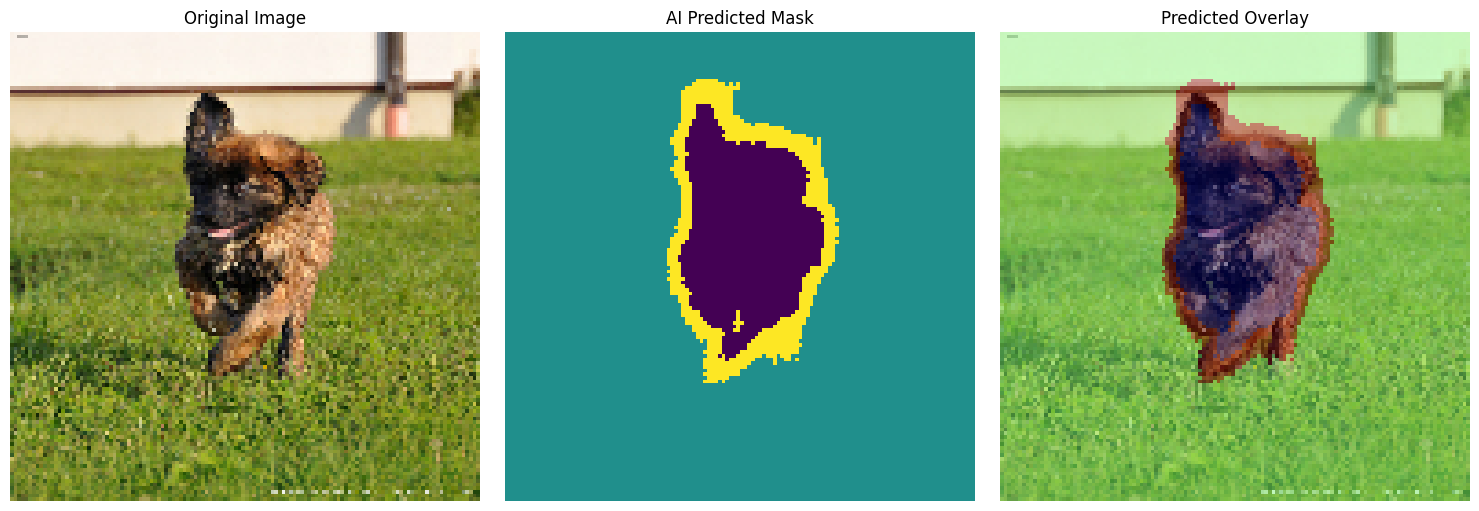

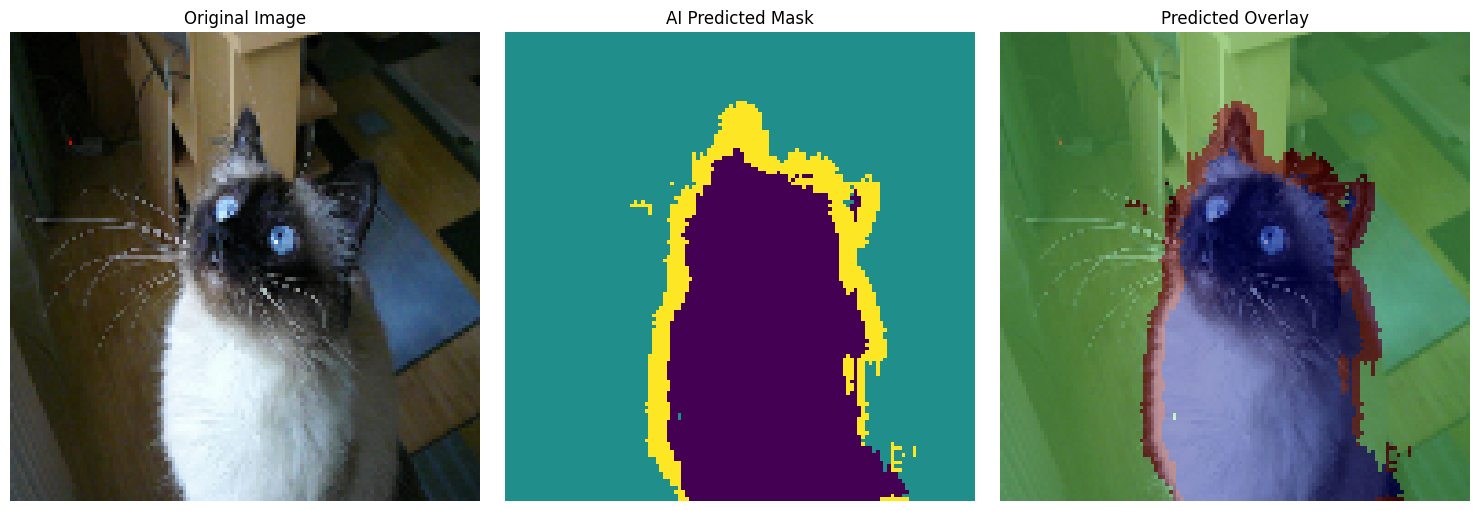

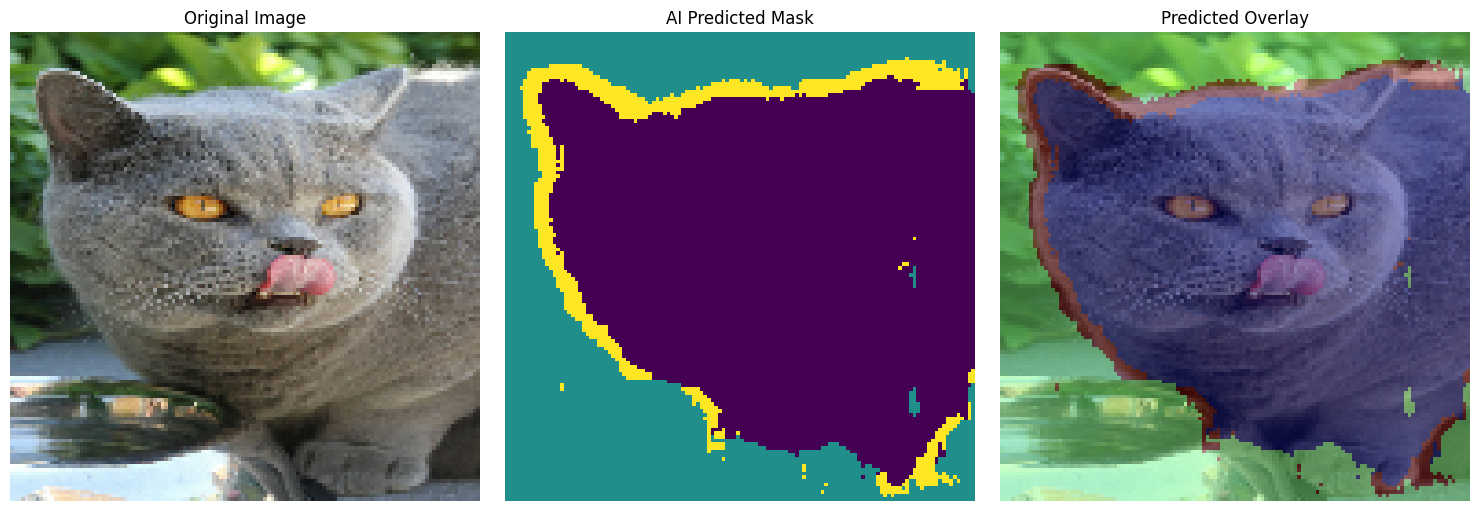

In [9]:
def create_mask(pred_mask):
    """Takes the highest probability class for each pixel."""
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

def show_predictions(dataset=None, num=3):
    """Visualizes True vs Predicted masks on multiple test images."""
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = model.predict(image, verbose=0)
            predicted_mask = create_mask(pred_mask)
            
            plt.figure(figsize=(15, 5))
            
            # Original Image
            plt.subplot(1, 3, 1)
            plt.title("Original Image")
            plt.imshow(tf.keras.preprocessing.image.array_to_img(image[0]))
            plt.axis('off')
            
            # Predicted Mask
            plt.subplot(1, 3, 2)
            plt.title("AI Predicted Mask")
            plt.imshow(tf.keras.preprocessing.image.array_to_img(predicted_mask), cmap='viridis')
            plt.axis('off')
            
            # Overlay
            plt.subplot(1, 3, 3)
            plt.title("Predicted Overlay")
            plt.imshow(tf.keras.preprocessing.image.array_to_img(image[0]))
            plt.imshow(np.squeeze(predicted_mask), cmap='jet', alpha=0.4)
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()

print("Generating AI Predictions on Unseen Test Data...")
show_predictions(test_dataset, 3)

---
## Conclusion!

Congratulations! You have successfully stepped beyond mere classification and bounding boxes.

By building a **U-Net**, you constructed a network capable of classifying *individual pixels*, allowing the AI to draw perfect shapes and boundaries around objects in complex scenes. This exact architecture is the foundation for self-driving cars (segmenting the road from the sidewalk) and advanced medical imaging diagnostics!

## Instance Segmentation:
Instance Segmentation is a computer vision task that identifies, classifies, and creates a separate pixel-level mask for each individual object instance in an image, even when multiple objects belong to the same class.

In [1]:
from ultralytics import YOLO
model = YOLO('yolov8n-seg.pt')

In [2]:
model.train(
    data = r'E:\NAVTTC-AI-Course\datasets\segmentation.yolov8\data.yaml',
    epochs=20,               # Increase to 50 for real-world precision
    imgsz=416,              # Safe image tensor sizing
    batch=16, 
)

Ultralytics 8.4.41  Python-3.10.20 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1070 with Max-Q Design, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\NAVTTC-AI-Course\datasets\segmentation.yolov8\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001A1079DEDA0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004, 


image 1/1 E:\NAVTTC-AI-Course\datasets\segmentation.yolov8\train\images\CT-1-2-246-352-63-1-5171859287743358746-10402486388650439320_png.rf.HDNohWW7AsjppzQz3kRH.png: 416x416 1 body, 1 cord, 1 paru kanan, 1 paru kiri, 94.7ms
Speed: 3.2ms preprocess, 94.7ms inference, 6.7ms postprocess per image at shape (1, 3, 416, 416)


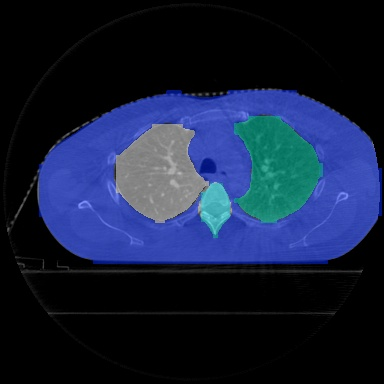

In [5]:
import cv2
from IPython.display import Image, display
from ultralytics import YOLO

# 1. Load your Custom Model
# model = YOLO(r'E:\NAVTTC-AI-Course\Month 02\Week 08\Notebooks\runs\segment\train-4\weights\best.pt')

# 2. Run prediction
img_path = r'E:\NAVTTC-AI-Course\datasets\segmentation.yolov8\train\images\CT-1-2-246-352-63-1-5171859287743358746-10402486388650439320_png.rf.HDNohWW7AsjppzQz3kRH.png'
results = model.predict(img_path)

# 3. Generate the image with masks/boxes drawn on it
annotated_image = results[0].plot(boxes=False)

# 4. Save the image temporarily and display it using Jupyter's native Image viewer!
cv2.imwrite('temp_prediction.jpg', annotated_image)
display(Image('temp_prediction.jpg', width=600))
